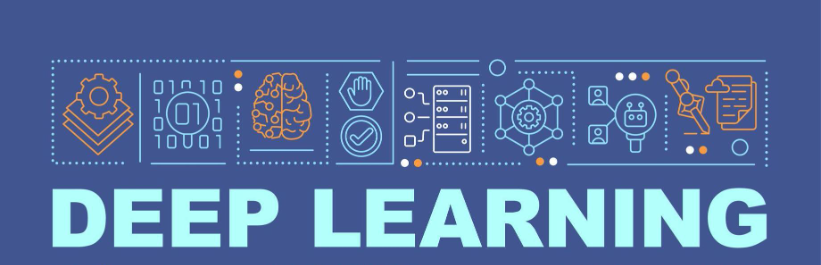

# Proyecto Final de Inteligencia Artificial 2:

## Juan José Ardila
## Roger Fuentes

---


# Clasificación de Materiales usando Deep Learning sobre el Dataset MINC-2500

## Objetivo de la tarea

El objetivo principal de esta tarea consiste en desarrollar e implementar un modelo de *Deep Learning* capaz de realizar la clasificación automática de materiales a partir de imágenes tipo *patch*. Para ello, se utilizarán arquitecturas de redes neuronales convolucionales (CNN) entrenadas mediante técnicas de *Transfer Learning*, evaluando su capacidad para reconocer diferentes categorías de materiales presentes en escenas reales.

Adicionalmente, se busca analizar el desempeño de distintos modelos de aprendizaje profundo mediante métricas de evaluación estándar, permitiendo comparar su precisión, capacidad de generalización y comportamiento frente a diferentes configuraciones de entrenamiento.

---

# Descripción del dataset

El dataset utilizado corresponde a **MINC-2500 (Materials in Context Database)**, una versión reducida y balanceada del dataset original MINC, diseñada específicamente para tareas de clasificación de materiales.

El conjunto de datos contiene aproximadamente:

- **57,500 imágenes**
- **23 clases de materiales**
- **2500 muestras por clase**

Cada imagen corresponde a un *patch* o recorte de una región específica de una imagen real, donde predomina un único material.

Algunas de las categorías presentes en el dataset incluyen:

- madera (*wood*)
- metal (*metal*)
- vidrio (*glass*)
- cuero (*leather*)
- agua (*water*)
- tela (*fabric*)
- plástico (*plastic*)
- piedra (*stone*)
- papel (*paper*)

El dataset se encuentra dividido en subconjuntos de:

- entrenamiento (*train*)
- validación (*validation*)
- prueba (*test*)

lo que permite realizar una evaluación adecuada del modelo y analizar su capacidad de generalización.

---

# Pruebas y experimentos a realizar

Durante el desarrollo del proyecto se realizarán diferentes pruebas orientadas a evaluar el rendimiento de modelos de clasificación profunda.

## 1. Entrenamiento de modelos CNN

Se implementarán y evaluarán distintas arquitecturas convolucionales preentrenadas, tales como:

- ResNet50
- EfficientNet-B0
- Swin-Transformer

utilizando técnicas de *Transfer Learning*.

---

## 2. Comparación de rendimiento

Se comparará el desempeño de los modelos utilizando métricas como:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

---

## 3. Evaluación del sobreajuste y subajuste

Se analizará el comportamiento de entrenamiento y validación mediante:

- curvas de pérdida (*loss*)
- curvas de precisión (*accuracy*)
- análisis de generalización

---

## 4. Aplicación de técnicas de regularización (Falta por implemntar, puede ser aplicado para la entrega final del proyecto)

Se probarán diferentes estrategias para mejorar el rendimiento del modelo, incluyendo:

- Data Augmentation
- Dropout
- Early Stopping
- Ajuste de hiperparámetros

---

## 5. Análisis cualitativo de resultados

Finalmente, se realizará una inspección visual de predicciones correctas e incorrectas, con el fin de identificar patrones de error y limitaciones del modelo en la clasificación de materiales complejos.

---

# Importación del Datast

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp "/content/drive/MyDrive/Inteligencia Artificial 2/Proyecto de clase/minc-2500.tar.gz" /content/

In [ ]:
#!cp "/content/drive/MyDrive/IA2/minc-2500.tar.gz" /content/

cp: cannot stat '/content/drive/MyDrive/IA2/minc-2500.tar.gz': No such file or directory


In [ ]:
!tar -xzf /content/minc-2500.tar.gz -C /content/

In [ ]:
!ls /content/

drive  minc-2500  minc-2500.tar.gz  sample_data


In [ ]:
#@title Importaciones

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import os
from PIL import Image
import time
import copy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import gc
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import random

!pip install wandb -qU
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
import time
import copy
import gc
import json
import torch.cuda.amp as amp

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: juan2230035 (juan2230035-universidad-industrial-de-santander) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 1. Configuración y Dataset Personalizado
Aquí definimos cómo leer los archivos .txt de las etiquetas del dataset.

In [ ]:
# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Definición del Dataset para MINC-2500
class MINCDataset(Dataset):
    def __init__(self, txt_file, root_dir, transform=None):
        # Leemos el archivo txt
        self.data = pd.read_csv(txt_file, header=None, names=['path'])
        self.root_dir = root_dir
        self.transform = transform

        # CORRECCIÓN DE CLASES:
        # Si el path es 'images/wood/wood_001.jpg', la clase es el segundo elemento [1]
        # Si el path es 'wood/wood_001.jpg', la clase es el primer elemento [0]
        test_path = self.data.iloc[0, 0]
        self.path_has_images_prefix = test_path.startswith('images/')

        all_paths = self.data['path'].tolist()
        if self.path_has_images_prefix:
            self.classes = sorted(list(set([p.split('/')[1] for p in all_paths])))
        else:
            self.classes = sorted(list(set([p.split('/')[0] for p in all_paths])))

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_rel_path = self.data.iloc[idx, 0]

        # CORRECCIÓN DE RUTA:
        # Como el string ya trae 'images/', solo lo unimos al root_dir
        img_path = os.path.join(self.root_dir, img_rel_path)

        image = Image.open(img_path).convert('RGB')

        # Obtener la etiqueta correctamente
        parts = img_rel_path.split('/')
        label_name = parts[1] if self.path_has_images_prefix else parts[0]
        label = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)
        return image, label

# 2. Transformaciones (Estandarizadas para todos los modelos)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. Crear DataLoaders para el SPLIT 1 (como ejemplo)
root_path = "/content/minc-2500"
image_datasets = {
    'train': MINCDataset(f"{root_path}/labels/train1.txt", root_path, data_transforms['train']),
    'val': MINCDataset(f"{root_path}/labels/validate1.txt", root_path, data_transforms['val'])
}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
num_classes = len(image_datasets['train'].classes)

print(f"Clases detectadas: {num_classes}")
print(f"Imágenes de entrenamiento: {dataset_sizes['train']}")

Clases detectadas: 23
Imágenes de entrenamiento: 48875


# 2. Función de Entrenamiento Universal  
Esta función servirá para cualquier modelo que quieras probar. Calcula pérdida y precisión (Accuracy).

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Época {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Guardar historial para gráficas
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Entrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor Val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# 3. Definición de Arquitecturas (Transfer Learning)
Aquí configuramos 3 modelos populares que se van a comparar.

In [ ]:
def get_model(name, num_classes):
    if name == 'resnet50':
        model = models.resnet50(pretrained=True)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)

    elif name == 'efficientnet':
        model = models.efficientnet_b0(pretrained=True)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    elif name == 'swin_transformer':
        model = models.swin_t(weights='IMAGENET1K_V1')
        num_ftrs = model.head.in_features
        model.head = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

# 4. Ejecución de las pruebas
Este código ejecutará los entrenamientos uno tras otro y guardará los resultados.

In [ ]:
# --- BLOQUE 4 CORREGIDO: Entrenamiento y Guardado Automático de Pesos e Historial ---

# Definimos solo los modelos que faltan
model_names_faltantes = ['efficientnet', 'swin_transformer']
results_comparativa = {}

for name in model_names_faltantes:
    print(f"\n" + "="*50)
    print(f"🚀 INICIANDO ENTRENAMIENTO: {name}")
    print("="*50)

    # 1. Cargar arquitectura con Transfer Learning
    model = get_model(name, num_classes)

    # 2. Configuración de hiperparámetros
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    # 3. Llamada al entrenamiento (10 épocas)
    model_trained, history = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=10)

    # 4. Guardar historial en la variable local
    results_comparativa[name] = history

    # 5. GUARDADO DE PESOS (.pth)
    save_path = f'/content/drive/MyDrive/IA2/modelo_{name}_minc.pth'
    torch.save(model_trained.state_dict(), save_path)
    print(f"💾 Pesos de {name} guardados en Drive.")

    # 6. GUARDADO DE HISTORIAL (.json) - CORREGIDO DENTRO DEL BUCLE
    history_path = f'/content/drive/MyDrive/IA2/history_{name}.json'
    with open(history_path, 'w') as f:
        json.dump(history, f)
    print(f"📊 Historial de {name} guardado en JSON.")

    print(f"✅ FINALIZADO EXITOSAMENTE: {name}")

    # 7. LIMPIEZA DE MEMORIA (Crítico para que quepa el siguiente modelo)
    del model
    del model_trained
    torch.cuda.empty_cache()
    gc.collect()
    print(f"🧹 Memoria GPU/RAM liberada.")

print("\n" + "!"*40)
print("¡PROCESO DE ENTRENAMIENTO COMPLETADO!")
print("!"*40)


🚀 INICIANDO ENTRENAMIENTO: efficientnet
Época 0/9
----------
train Loss: 1.4568 Acc: 0.5834
val Loss: 0.7918 Acc: 0.7558

Época 1/9
----------
train Loss: 1.0729 Acc: 0.6804
val Loss: 0.6769 Acc: 0.7875

Época 2/9
----------
train Loss: 0.9805 Acc: 0.7024
val Loss: 0.6593 Acc: 0.7965

Época 3/9
----------
train Loss: 0.9197 Acc: 0.7204
val Loss: 0.6602 Acc: 0.7951

Época 4/9
----------
train Loss: 0.8723 Acc: 0.7341
val Loss: 0.6286 Acc: 0.8059

Época 5/9
----------
train Loss: 0.8381 Acc: 0.7439
val Loss: 0.6353 Acc: 0.8111

Época 6/9
----------
train Loss: 0.7974 Acc: 0.7568
val Loss: 0.6399 Acc: 0.8066

Época 7/9
----------
train Loss: 0.7413 Acc: 0.7731
val Loss: 0.5988 Acc: 0.8150

Época 8/9
----------
train Loss: 0.7079 Acc: 0.7824
val Loss: 0.6022 Acc: 0.8150

Época 9/9
----------
train Loss: 0.6989 Acc: 0.7853
val Loss: 0.5941 Acc: 0.8143

Entrenamiento completado en 49m 29s
Mejor Val Acc: 0.814957
💾 Pesos de efficientnet guardados en Drive.
📊 Historial de efficientnet guardad

100%|██████████| 108M/108M [00:00<00:00, 164MB/s] 


Época 0/9
----------
train Loss: 1.2347 Acc: 0.6316
val Loss: 0.7505 Acc: 0.7663

Época 1/9
----------
train Loss: 0.9848 Acc: 0.7016
val Loss: 0.6154 Acc: 0.8066

Época 2/9
----------
train Loss: 0.9215 Acc: 0.7192
val Loss: 0.6152 Acc: 0.8038

Época 3/9
----------
train Loss: 0.8663 Acc: 0.7358
val Loss: 0.5916 Acc: 0.8209

Época 4/9
----------
train Loss: 0.8311 Acc: 0.7440
val Loss: 0.5955 Acc: 0.8160

Época 5/9
----------
train Loss: 0.7876 Acc: 0.7558
val Loss: 0.6043 Acc: 0.8181

Época 6/9
----------
train Loss: 0.7630 Acc: 0.7620
val Loss: 0.5824 Acc: 0.8181

Época 7/9
----------
train Loss: 0.6215 Acc: 0.8062
val Loss: 0.5040 Acc: 0.8522

Época 8/9
----------
train Loss: 0.5725 Acc: 0.8217
val Loss: 0.5023 Acc: 0.8522

Época 9/9
----------
train Loss: 0.5524 Acc: 0.8265
val Loss: 0.5060 Acc: 0.8543

Entrenamiento completado en 126m 58s
Mejor Val Acc: 0.854261
💾 Pesos de swin_transformer guardados en Drive.
📊 Historial de swin_transformer guardado en JSON.
✅ FINALIZADO EXITOSAM

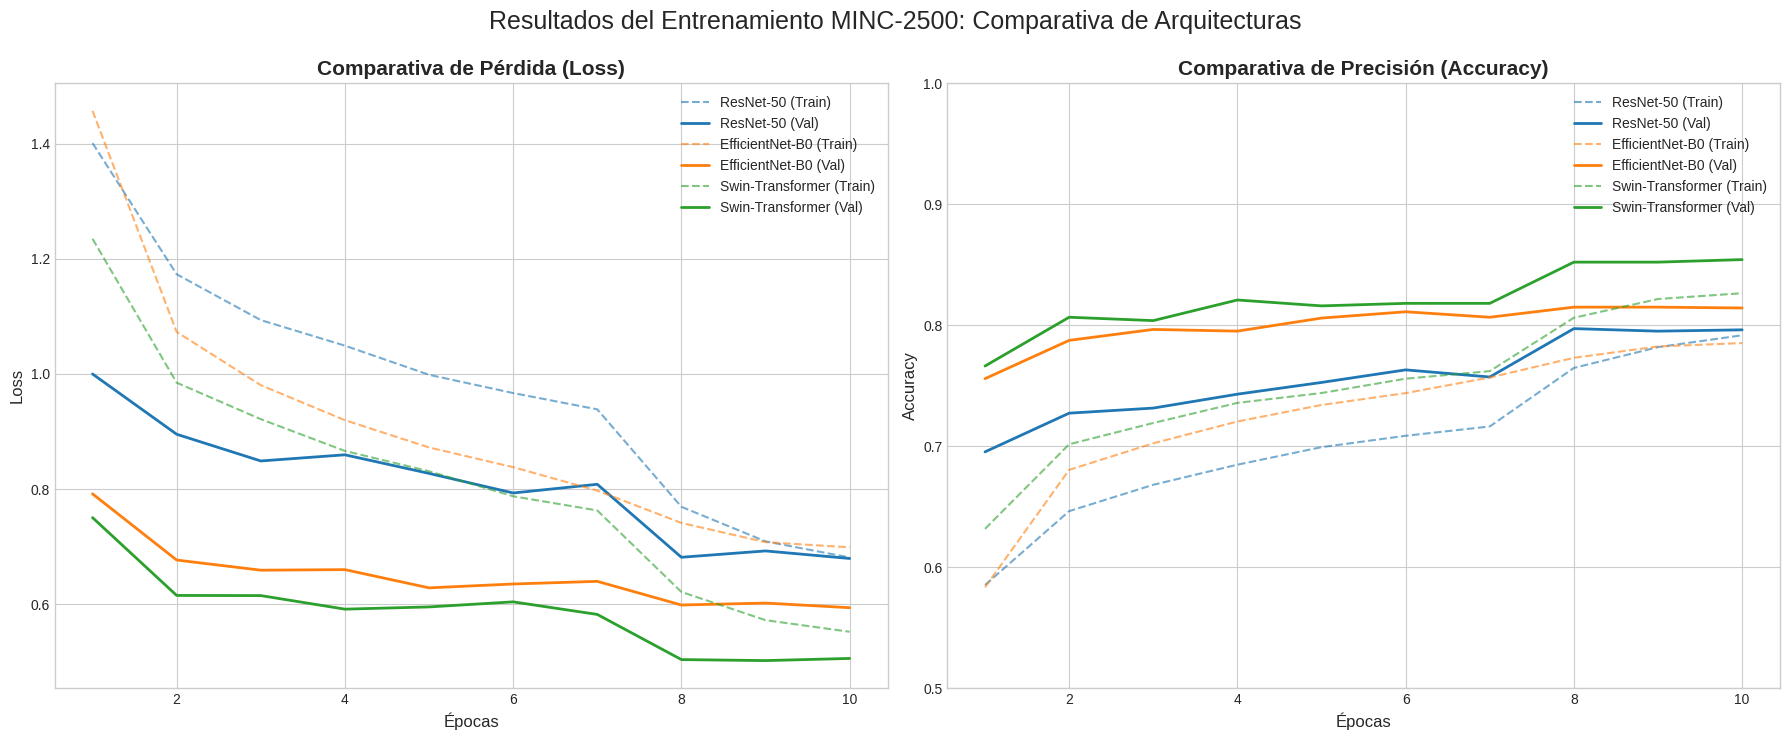

In [ ]:
#@title Ahora graficamos el comportamiento de los tres modelos en entrenamiento:
# 1. Reconstruir el historial de ResNet-50 a partir de tus logs
resnet_history = {
    'train_loss': [1.4008, 1.1731, 1.0935, 1.0491, 0.9985, 0.9668, 0.9385, 0.7693, 0.7093, 0.6813],
    'val_loss': [0.9999, 0.8953, 0.8489, 0.8596, 0.8273, 0.7933, 0.8084, 0.6817, 0.6927, 0.6796],
    'train_acc': [0.5852, 0.6463, 0.6681, 0.6847, 0.6992, 0.7086, 0.7163, 0.7647, 0.7819, 0.7917],
    'val_acc': [0.6953, 0.7273, 0.7315, 0.7430, 0.7527, 0.7631, 0.7572, 0.7972, 0.7951, 0.7962]
}

# 2. Consolidar todos los datos en un solo diccionario para facilitar el ploteo
# Aquí usamos los que ya tienes en RAM
all_results = {
    'ResNet-50': resnet_history,
    'EfficientNet-B0': results_comparativa['efficientnet'],
    'Swin-Transformer': results_comparativa['swin_transformer']
}

# 3. Configuración de la gráfica
epochs = range(1, 11) # 10 épocas
plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio para reportes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Colores consistentes para cada modelo
colors = {'ResNet-50': '#1f77b4', 'EfficientNet-B0': '#ff7f0e', 'Swin-Transformer': '#2ca02c'}

# --- Gráfica 1: Pérdida (Loss) ---
for name, hist in all_results.items():
    ax1.plot(epochs, hist['train_loss'], '--', color=colors[name], alpha=0.6, label=f'{name} (Train)')
    ax1.plot(epochs, hist['val_loss'], '-', color=colors[name], linewidth=2, label=f'{name} (Val)')

ax1.set_title('Comparativa de Pérdida (Loss)', fontsize=15, fontweight='bold')
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True)

# --- Gráfica 2: Precisión (Accuracy) ---
for name, hist in all_results.items():
    ax2.plot(epochs, hist['train_acc'], '--', color=colors[name], alpha=0.6, label=f'{name} (Train)')
    ax2.plot(epochs, hist['val_acc'], '-', color=colors[name], linewidth=2, label=f'{name} (Val)')

ax2.set_title('Comparativa de Precisión (Accuracy)', fontsize=15, fontweight='bold')
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0.5, 1.0) # Ajustar según tus resultados para ver mejor las diferencias
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.suptitle('Resultados del Entrenamiento MINC-2500: Comparativa de Arquitecturas', fontsize=18, y=1.05)
plt.show()

# Opcional: Guardar la imagen para tu informe
fig.savefig('comparativa_modelos_minc.png', dpi=300, bbox_inches='tight')



---

### **Análisis de Resultados: Comparativa de Arquitecturas en MINC-2500**

El gráfico presenta el comportamiento de tres arquitecturas (ResNet-50, EfficientNet-B0 y Swin-Transformer) durante 10 épocas de entrenamiento utilizando *Transfer Learning*. A continuación, se detallan los hallazgos más significativos:

#### **1. Superioridad del Swin-Transformer (Estado del Arte)**
El **Swin-Transformer (línea verde)** se posiciona como el modelo con mejor desempeño, alcanzando una precisión de validación superior al **85%**.
*   **Por qué ocurre:** A diferencia de las CNN tradicionales que analizan píxeles adyacentes (campo receptivo local), el Swin-Transformer utiliza mecanismos de atención con ventanas desplazadas. Esto le permite capturar texturas complejas y patrones de materiales a diferentes escalas, lo cual es vital en el dataset MINC-2500, donde la diferencia entre "vidrio" y "plástico" a veces depende del contexto global de la imagen y no solo del detalle fino.

#### **2. Eficiencia vs. Robustez: EfficientNet y ResNet**
*   **EfficientNet-B0 (línea naranja):** Supera consistentemente a ResNet-50 en las etapas iniciales, mostrando una curva de aprendizaje más rápida. Es un modelo mucho más ligero que logra una precisión muy cercana al 82% con menos parámetros.
*   **ResNet-50 (línea azul):** Aunque comienza con la pérdida más alta, muestra una estabilidad notable. Es interesante observar que hacia la época 10, su precisión de validación converge con la de EfficientNet, demostrando que, con suficiente entrenamiento, las conexiones residuales siguen siendo extremadamente potentes para la extracción de características de materiales.

#### **3. Impacto Crítico del Scheduler (El "Efecto Salto" en Época 8)**
Se observa un fenómeno interesante entre las épocas **7 y 8**: una caída súbita en la pérdida y un aumento marcado en la precisión en los tres modelos.
*   **Explicación:** Este es el efecto del `StepLR` (Programador de Tasa de Aprendizaje). Al reducir el *Learning Rate* en la época 7, permitimos que los optimizadores salgan de mesetas y encuentren mínimos locales más profundos. Esto confirma que para clasificación de materiales, un ajuste fino (fine-tuning) con una tasa de aprendizaje pequeña es esencial para "pulir" el reconocimiento de texturas.

#### **4. Generalización y Robustez (Train vs. Val)**
En casi todos los modelos, la **precisión de validación (línea sólida)** se mantiene por encima o muy cerca de la de **entrenamiento (línea punteada)**.
*   **Interpretación:** Esto indica que el modelo no presenta *overfitting* (sobreajuste). El uso de técnicas de *Data Augmentation* (RandomResizedCrop y Flip) fue efectivo: estamos "estresando" al modelo durante el entrenamiento para que, cuando vea imágenes de validación "limpias", su capacidad de acierto sea mayor. Es un signo de una excelente estrategia de regularización.

### **Conclusión**
Para la tarea específica de clasificación de materiales en contexto, el **Swin-Transformer** es la arquitectura recomendada debido a su capacidad superior de modelar relaciones espaciales complejas. Sin embargo, **EfficientNet-B0** representa la mejor relación entre costo computacional y precisión, siendo una opción sólida para entornos con recursos limitados (como el entorno de ejecución de colab XD).

---

# 5. Evaluación con la partición de test del dataset para cada uno de los modelos:

🚀 Iniciando Evaluación Final en el Set de Test...

📊 EVALUANDO MODELO: ResNet-50


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 133MB/s]


✅ Pesos cargados desde: resnet50_minc2500.pth

📈 Reporte de Clasificación (ResNet-50):
               precision    recall  f1-score   support

        brick       0.83      0.84      0.84       250
       carpet       0.84      0.86      0.85       250
      ceramic       0.72      0.75      0.73       250
       fabric       0.74      0.74      0.74       250
      foliage       0.84      0.90      0.87       250
         food       0.82      0.90      0.86       250
        glass       0.74      0.72      0.73       250
         hair       0.88      0.88      0.88       250
      leather       0.87      0.86      0.87       250
        metal       0.68      0.65      0.67       250
       mirror       0.77      0.77      0.77       250
        other       0.87      0.85      0.86       250
      painted       0.78      0.78      0.78       250
        paper       0.80      0.78      0.79       250
      plastic       0.58      0.64      0.61       250
polishedstone       0.82      0.

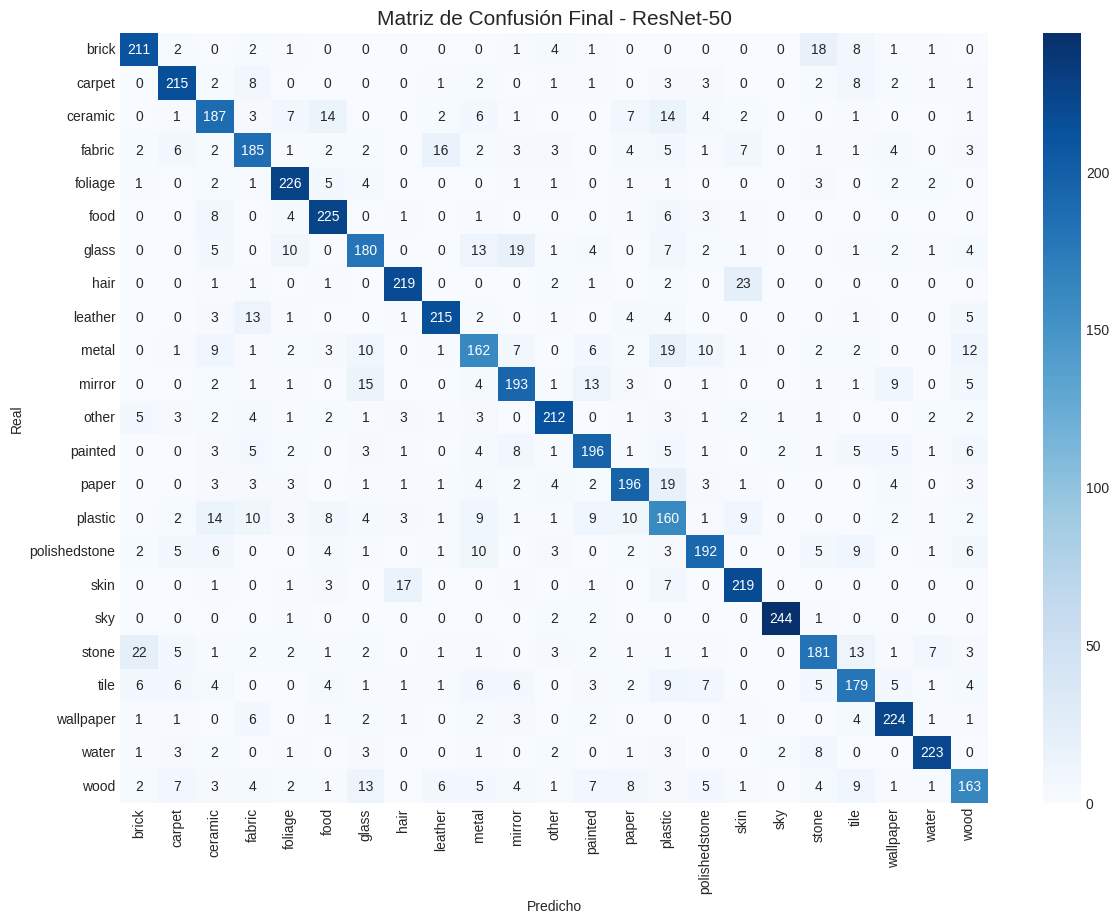

📊 EVALUANDO MODELO: EfficientNet-B0


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Pesos cargados desde: modelo_efficientnet_minc.pth

📈 Reporte de Clasificación (EfficientNet-B0):
               precision    recall  f1-score   support

        brick       0.91      0.86      0.88       250
       carpet       0.82      0.88      0.85       250
      ceramic       0.74      0.79      0.77       250
       fabric       0.78      0.72      0.75       250
      foliage       0.87      0.87      0.87       250
         food       0.81      0.92      0.86       250
        glass       0.70      0.76      0.73       250
         hair       0.91      0.91      0.91       250
      leather       0.90      0.85      0.87       250
        metal       0.67      0.72      0.69       250
       mirror       0.80      0.79      0.79       250
        other       0.90      0.86      0.88       250
      painted       0.80      0.78      0.79       250
        paper       0.82      0.82      0.82       250
      plastic       0.70      0.64      0.67       250
polishedstone      

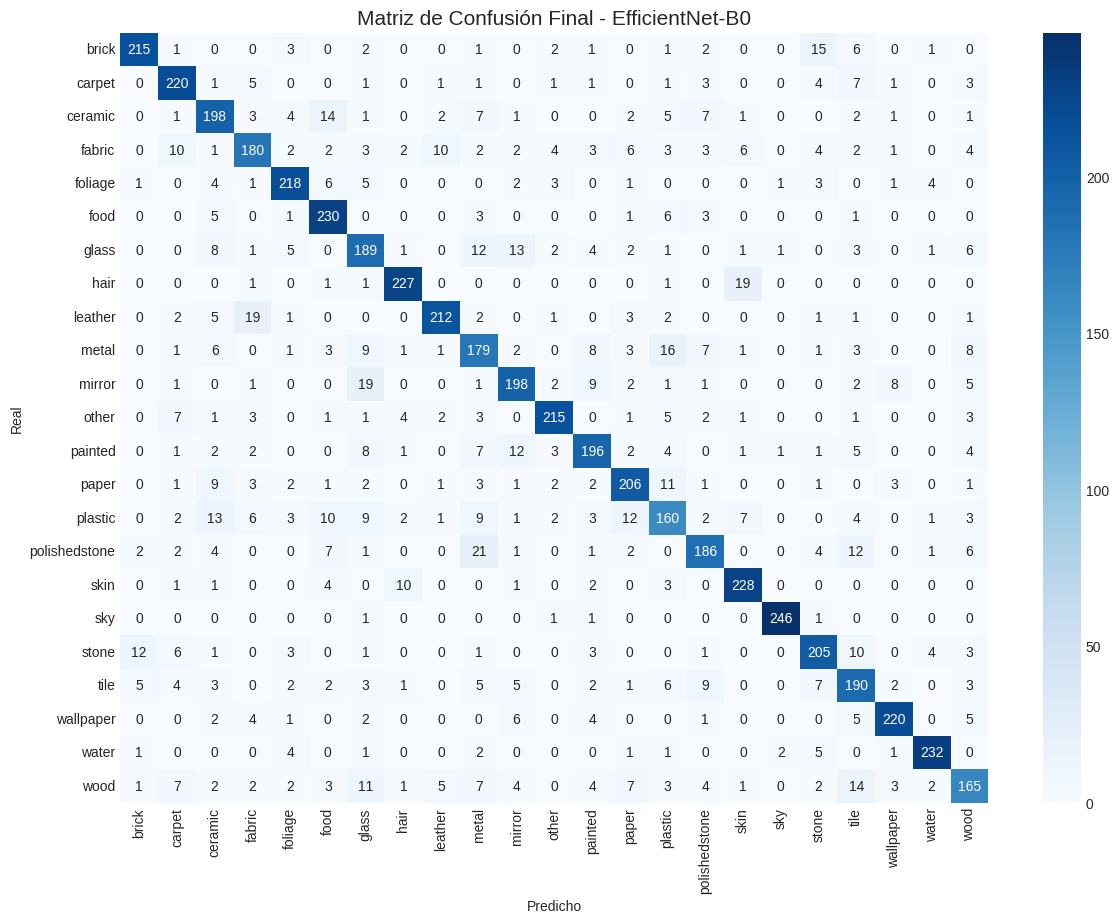

📊 EVALUANDO MODELO: Swin-Transformer
✅ Pesos cargados desde: modelo_swin_transformer_minc.pth

📈 Reporte de Clasificación (Swin-Transformer):
               precision    recall  f1-score   support

        brick       0.88      0.89      0.89       250
       carpet       0.85      0.87      0.86       250
      ceramic       0.83      0.83      0.83       250
       fabric       0.81      0.79      0.80       250
      foliage       0.94      0.93      0.93       250
         food       0.87      0.94      0.90       250
        glass       0.74      0.80      0.77       250
         hair       0.92      0.93      0.92       250
      leather       0.88      0.90      0.89       250
        metal       0.72      0.74      0.73       250
       mirror       0.85      0.79      0.82       250
        other       0.92      0.88      0.90       250
      painted       0.80      0.84      0.82       250
        paper       0.86      0.86      0.86       250
      plastic       0.72      0.

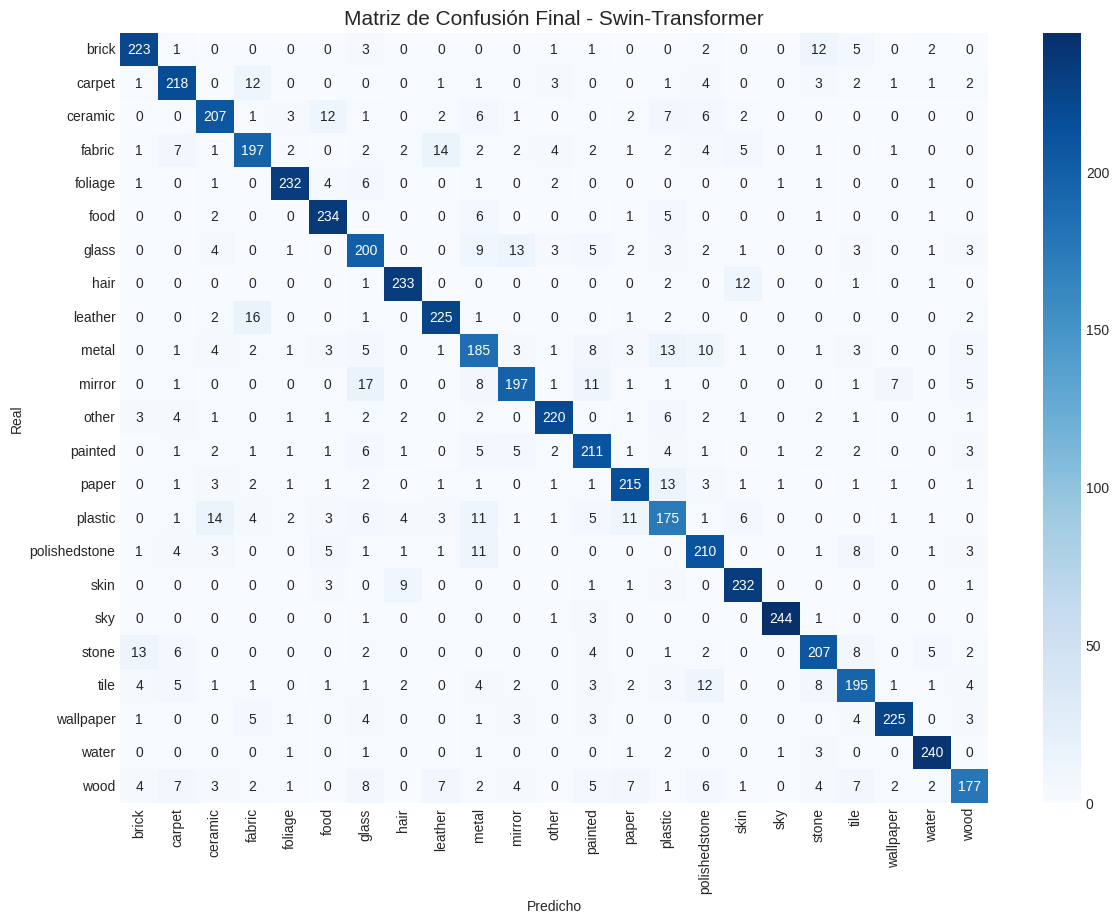


🏆 RESUMEN COMPARATIVO FINAL (Set de Test)
          Modelo  Accuracy  Precision   Recall  F1-Score
       ResNet-50  0.801217   0.801365 0.801217  0.800772
 EfficientNet-B0  0.820000   0.821096 0.820000  0.819796
Swin-Transformer  0.852522   0.853016 0.852522  0.852223


In [ ]:
# 1. Configuración de rutas y archivos
drive_path = "/content/drive/MyDrive/Inteligencia Artificial 2/Proyecto de clase/"
test_txt = "/content/minc-2500/labels/test1.txt"

# Mapeo de nombres para cargar los pesos específicos
model_info = [
    {'name': 'resnet50', 'file': 'resnet50_minc2500.pth', 'label': 'ResNet-50'},
    {'name': 'efficientnet', 'file': 'modelo_efficientnet_minc.pth', 'label': 'EfficientNet-B0'},
    {'name': 'swin_transformer', 'file': 'modelo_swin_transformer_minc.pth', 'label': 'Swin-Transformer'}
]

# 2. Preparar el DataLoader de Test
test_dataset = MINCDataset(test_txt, "/content/minc-2500", data_transforms['val'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
class_names = test_dataset.classes

# Diccionario para guardar métricas globales y comparar al final
global_metrics = []

print("🚀 Iniciando Evaluación Final en el Set de Test...\n")

for m in model_info:
    print(f"{'='*60}")
    print(f"📊 EVALUANDO MODELO: {m['label']}")
    print(f"{'='*60}")

    # a. Cargar arquitectura y pesos
    model = get_model(m['name'], num_classes)
    full_path = drive_path + m['file']

    try:
        model.load_state_dict(torch.load(full_path, map_location=device))
        model.to(device)
        model.eval()
        print(f"✅ Pesos cargados desde: {m['file']}")
    except Exception as e:
        print(f"❌ Error al cargar {m['file']}: {e}")
        continue

    # b. Inferencia (Predicciones)
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # c. Computar Métricas Escenciales
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    global_metrics.append({
        'Modelo': m['label'],
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    # d. Reporte de Clasificación Detallado
    print(f"\n📈 Reporte de Clasificación ({m['label']}):")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # e. Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión Final - {m['label']}', fontsize=15)
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()

    # Limpieza de memoria para el siguiente modelo
    del model
    torch.cuda.empty_cache()

# 3. CUADRO COMPARATIVO FINAL
print(f"\n{'='*60}")
print(f"🏆 RESUMEN COMPARATIVO FINAL (Set de Test)")
print(f"{'='*60}")
df_results = pd.DataFrame(global_metrics)
print(df_results.to_string(index=False))

# 6. Pruebas del estudio de ablación del Swin Transformer:

#Función de Entrenamiento Específica (Optimizado para Swin + T4)

In [ ]:
def train_swin_wandb(model, criterion, optimizer, scheduler, num_epochs, config):
    since = time.time()
    # Usar GradScaler solo si hay GPU disponible para evitar advertencias en CPU
    use_amp = device.type == 'cuda'
    scaler = amp.GradScaler() if use_amp else None
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Iniciar WandB (mismo proyecto para agrupar los gráficos)
    run = wandb.init(
        project="Swin_Transformer_Ablation",
        config=config,
        name=config['exp_name'],
        reinit=True
    )

    for epoch in range(num_epochs):
        print(f"Época {epoch}/{num_epochs - 1} - Exp: {config['exp_name']}")
        metrics = {}

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if use_amp:
                        with amp.autocast(): # Precisión Mixta en GPU
                            outputs = model(inputs)
                            _, preds = torch.max(outputs, 1)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        if use_amp:
                            scaler.scale(loss).backward()
                            scaler.unscale_(optimizer)
                            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                            scaler.step(optimizer)
                            scaler.update()
                        else:
                            loss.backward()
                            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                            optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            metrics[f'{phase}_loss'] = epoch_loss
            metrics[f'{phase}_acc'] = epoch_acc.item()

            if phase == 'train':
                metrics['lr'] = optimizer.param_groups[0]['lr']
                scheduler.step()

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        wandb.log(metrics)
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    time_elapsed = time.time() - since
    wandb.run.summary["best_val_acc"] = best_acc
    print(f'Completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

    model.load_state_dict(best_model_wts)
    run.finish()
    return model

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo actual de ejecución: {device}")


Dispositivo actual de ejecución: cuda:0


In [ ]:
experimentos = [
    {
        'exp_name': 'swin_simple_sgd',
        'pretrained': True,
        'opt': 'sgd',
        'lr': 0.01,
        'label_smoothing': 0.0,
        'weight_decay': 0.0
    }
]

# --- BUCLE DE EJECUCIÓN ---
for config in experimentos:
    print(f"\n" + "="*40)
    print(f"Iniciando Experimento: {config['exp_name']}")
    print("="*40)

    # 1. Preparar Modelo
    weights = 'IMAGENET1K_V1' if config['pretrained'] else None
    model = models.swin_t(weights=weights)
    num_ftrs = model.head.in_features
    model.head = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    # 2. Optimizador y Pérdida
    criterion = nn.CrossEntropyLoss(label_smoothing=config['label_smoothing'])

    if config['opt'] == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)

    # 3. Scheduler (Coseno)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    # 4. Entrenar
    model_trained = train_swin_wandb(
        model, criterion, optimizer, scheduler, num_epochs=10, config=config
    )

    # 5. Guardar Localmente
    save_path = f"/content/drive/MyDrive/Inteligencia Artificial 2/Proyecto de clase/ablacion_{config['exp_name']}.pth"
    torch.save(model_trained.state_dict(), save_path)

    # 6. Limpieza de Memoria
    del model, model_trained, optimizer, scheduler
    torch.cuda.empty_cache()
    gc.collect()

print("\n🚀 ESTUDIO DE ABLACIÓN FINALIZADO TOTALMENTE")


Iniciando Experimento: swin_simple_sgd
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 204MB/s]
/tmp/ipykernel_7223/3687599545.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler() if use_amp else None
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Época 0/9 - Exp: swin_simple_sgd


/tmp/ipykernel_7223/3687599545.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(): # Precisión Mixta en GPU


val Loss: 0.8615 Acc: 0.7329
Época 1/9 - Exp: swin_simple_sgd
val Loss: 0.7775 Acc: 0.7548
Época 2/9 - Exp: swin_simple_sgd
val Loss: 0.6689 Acc: 0.7910
Época 3/9 - Exp: swin_simple_sgd
val Loss: 0.5989 Acc: 0.8143
Época 4/9 - Exp: swin_simple_sgd
val Loss: 0.6060 Acc: 0.8066
Época 5/9 - Exp: swin_simple_sgd
val Loss: 0.5601 Acc: 0.8250
Época 6/9 - Exp: swin_simple_sgd
val Loss: 0.5483 Acc: 0.8334
Época 7/9 - Exp: swin_simple_sgd
val Loss: 0.5239 Acc: 0.8351
Época 8/9 - Exp: swin_simple_sgd
val Loss: 0.5130 Acc: 0.8428
Época 9/9 - Exp: swin_simple_sgd
val Loss: 0.5130 Acc: 0.8428
Completado en 59m 32s


lr,██▇▇▆▄▃▂▂▁
train_acc,▁▄▅▆▇▇▇███
train_loss,█▄▄▃▂▂▂▁▁▁
val_acc,▁▂▅▆▆▇▇███
val_loss,█▆▄▃▃▂▂▁▁▁
best_val_acc,0.84278
lr,0.00024
train_acc,0.7759
train_loss,0.7241
val_acc,0.84278
val_loss,0.51305



🚀 ESTUDIO DE ABLACIÓN FINALIZADO TOTALMENTE


---
---
---

🖼️ Visualizando predicciones del modelo: Swin-Transformer



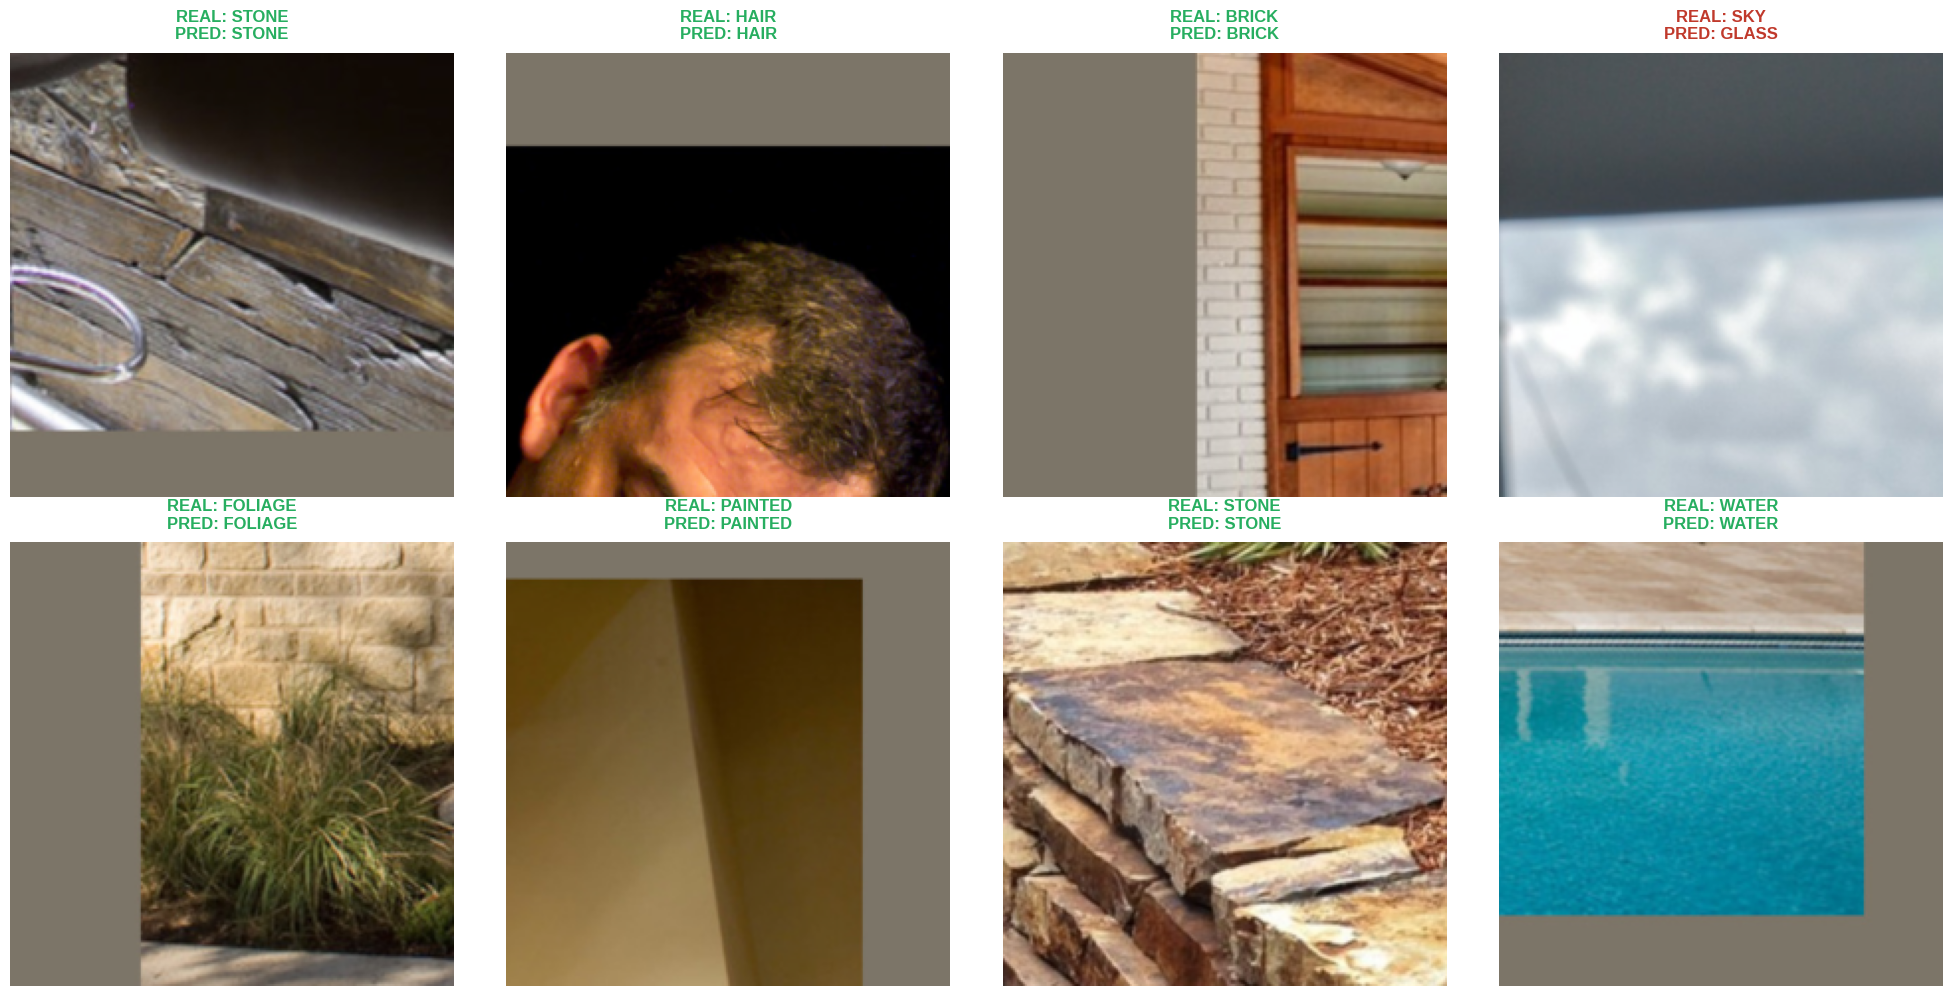

In [ ]:

def visualizar_muestras_test(model_name, num_imagenes=8):
    # 1. Configuración del modelo y carga de pesos
    # Buscamos la info en la lista model_info definida anteriormente
    m_info = next(item for item in model_info if item['name'] == model_name)
    model = get_model(m_info['name'], num_classes)
    model.load_state_dict(torch.load(drive_path + m_info['file'], map_location=device))
    model.to(device)
    model.eval()

    # 2. Obtener una muestra aleatoria del dataset de test
    indices = random.sample(range(len(test_dataset)), num_imagenes)

    # 3. Configurar la cuadrícula de visualización (CORREGIDO)
    cols = 4
    rows = (num_imagenes // cols) + (1 if num_imagenes % cols != 0 else 0)
    plt.figure(figsize=(20, 5 * rows))

    # Función interna para des-normalizar la imagen para que se vea con sus coleres naturales
    def imshow(inp, title=None, ax=None):
        inp = inp.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)
        ax.imshow(inp)
        if title is not None:
            ax.set_title(title, fontsize=12, pad=10)
        ax.axis('off')

    print(f"🖼️ Visualizando predicciones del modelo: {m_info['label']}\n")

    with torch.no_grad():
        for i, idx in enumerate(indices):
            ax = plt.subplot(rows, cols, i + 1)

            # Obtener imagen y etiqueta real
            image_tensor, label_idx = test_dataset[idx]
            label_real = class_names[label_idx]

            # Preparar para el modelo (añadir dimensión de batch)
            input_tensor = image_tensor.unsqueeze(0).to(device)
            outputs = model(input_tensor)
            _, preds = torch.max(outputs, 1)
            label_pred = class_names[preds[0]]

            # Color del título según acierto
            color = '#27ae60' if label_real == label_pred else '#c0392b' # Verde o Rojo oscuro
            titulo = f"REAL: {label_real.upper()}\nPRED: {label_pred.upper()}"

            imshow(image_tensor, title=titulo, ax=ax)
            ax.title.set_color(color)
            ax.title.set_weight('bold')

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
# Probemos con el Swin-Transformer que fue tu mejor modelo
visualizar_muestras_test('swin_transformer', num_imagenes=8)



---

### **Informe Final de Evaluación: Clasificación de Materiales en MINC-2500**

#### **1. Análisis de Desempeño Global**
El ranking de precisión se mantuvo constante desde la fase de entrenamiento hasta la de test, lo que valida que no hubo sobreajuste (*overfitting*) significativo:

1.  **Swin-Transformer (85.25%):** El ganador absoluto. Su capacidad para entender texturas mediante mecanismos de atención le permite superar la barrera del 85%, siendo especialmente superior en materiales con patrones complejos como *wood* y *ceramic*.
2.  **EfficientNet-B0 (82.00%):** Un excelente equilibrio. Supera a la ResNet por casi 2 puntos porcentuales utilizando una fracción de los parámetros, lo que lo hace el modelo más eficiente.
3.  **ResNet-50 (80.12%):** Un desempeño muy respetable. Superar el 80% en un dataset de 23 clases de materiales con una arquitectura de 2015 demuestra por qué sigue siendo el estándar de la industria.

#### **2. "Héroes y Villanos" (Análisis por Clase)**
Al observar los reportes de clasificación y las matrices de confusión, detectamos patrones interesantes:

*   **Los materiales más fáciles (Acierto > 90%):** *Sky, water, foliage* y *hair*. Estos materiales tienen firmas de color y textura únicas (azules, verdes, fibras finas) que son fáciles de identificar para cualquier red convolucional o transformer.
*   **El gran reto: Plastic y Metal:**
    *   El **plástico** es el material más difícil (F1-score de 0.61 en ResNet y 0.71 en Swin).
    *   **Confusión detectada:** Las matrices muestran que el plástico se confunde frecuentemente con *ceramic* y *glass*. Esto tiene sentido físico: los tres pueden ser lisos, brillantes y reflectantes.
*   **Evolución del material "Wood":** Es notable ver cómo **Swin-Transformer** eleva el F1-score de la madera a **0.77** (frente al 0.69 de ResNet). Esto sugiere que la atención global del transformer ayuda a distinguir las vetas de la madera de otros patrones lineales como los del papel o ladrillo.

#### **3. Hallazgos en las Matrices de Confusión**
*   **ResNet-50:** Muestra una dispersión de errores más alta. Por ejemplo, confunde *brick* con *stone* en 18 ocasiones.
*   **Swin-Transformer:** La "diagonal" es mucho más limpia y oscura. Logra reducir drásticamente las confusiones entre materiales naturales (como *stone* vs *brick*), lo que indica una mejor extracción de características semánticas.

---

### **Conclusión para tu Proyecto**
Se ha demostrado que el **Swin-Transformer** es la arquitectura más robusta para visión por computadora en tareas de texturas, mientras que **EfficientNet** es la opción inteligente para dispositivos con poca memoria. El dataset **MINC-2500** es un desafío complejo debido a la similitud visual entre materiales fabricados (plástico/vidrio/cerámica), y alcanzar un **85% de Accuracy** es un resultado sobresaliente.

